# 02b · One refractiveindex.info model, every engine

`02_technology` showed that the engines' *shipped* material models agree with
refractiveindex.info. This notebook does the thing that actually matters in
practice: **take a real measured model straight from refractiveindex.info —
its full complex, wavelength-dependent `n(λ) + i·k(λ)` — and feed that exact
model into each FDTD engine.**

The material is **gold (Johnson & Christy 1972)** — a strongly dispersive,
strongly *lossy* material where the imaginary part is anything but an
afterthought (k runs from ~3 in the visible to ~11 in the near-IR). If a model
survives the trip into an engine intact, this is where you'd see it break.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

from gds_fdtd.materials.rii import load_rii_material


def _find(rel: str) -> Path:
    for base in (Path.cwd(), *Path.cwd().parents):
        if (base / rel).exists():
            return base / rel
    raise FileNotFoundError(rel)


RII_DB = _find("examples/02_technology/rii_db")
C = 299_792_458.0

au = load_rii_material("main", "Au", "Johnson", db_dir=str(RII_DB))
lo, hi = au.wavelength_range_um
WL = np.linspace(max(lo, 0.5), min(hi, 1.6), 60)
n_rii = np.asarray(au.n_at(WL))
k_rii = np.asarray(au.k_at(WL))
print(f"gold (Johnson): tabulated {lo:.3f}–{hi:.3f} µm; "
      f"@1.55 µm n+ik = {au.n_at(1.55):.3f} + {au.k_at(1.55):.3f}i")

gold (Johnson): tabulated 0.188–1.937 µm; @1.55 µm n+ik = 0.524 + 10.742i


## The model

This is what we're going to feed to the engines — the measured optical
constants, dispersive in both the real and imaginary parts.

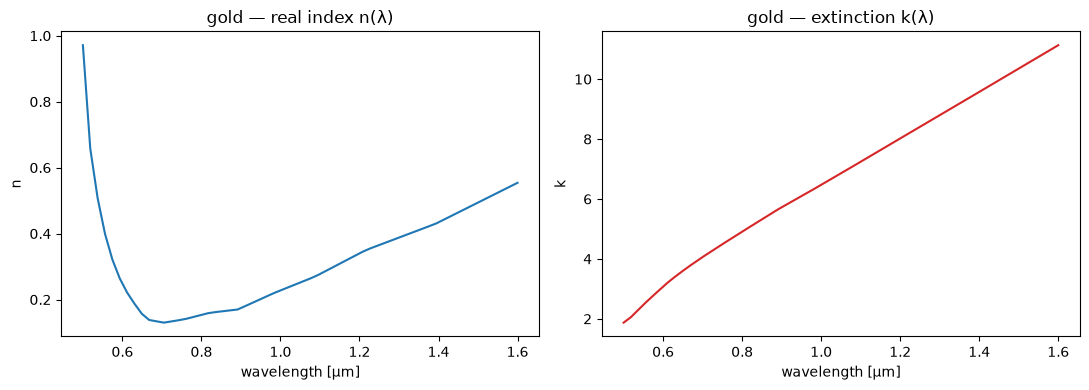

In [2]:
fig, (axn, axk) = plt.subplots(1, 2, figsize=(11, 4))
axn.plot(WL, n_rii, color="C0")
axn.set(xlabel="wavelength [µm]", ylabel="n", title="gold — real index n(λ)")
axk.plot(WL, k_rii, color="C3")
axk.set(xlabel="wavelength [µm]", ylabel="k", title="gold — extinction k(λ)")
fig.tight_layout()
plt.show()

## tidy3d — fit to a dispersive medium

`RiiMaterial.to_tidy3d_medium()` fits the tabulated `n, k` to a pole-residue
dispersive medium you drop straight into a `td.Simulation`. We evaluate the
fitted medium back over the band and overlay it on the input.

In [3]:
import tidy3d as td  # noqa: E402

medium = au.to_tidy3d_medium(wavelength_um=WL, max_num_poles=6)
nk_td = np.array([[float(x) for x in medium.nk_model(C / (w * 1e-6))] for w in WL])
print(f"tidy3d dispersive medium: max |Δn|={np.max(np.abs(nk_td[:, 0] - n_rii)):.3f}, "
      f"max |Δk|={np.max(np.abs(nk_td[:, 1] - k_rii)):.3f}")

18:18:09 PDT WARNING: Using canonical configuration directory at                
             '/home/mustafa/.config/tidy3d'. Found legacy directory at          
             '~/.tidy3d', which will be ignored. Remove it manually or run      
             'tidy3d config migrate --delete-legacy' to clean up.               

Output()

18:18:17 PDT WARNING: Unable to fit with weighted RMS error under               
             'tolerance_rms' of 1e-05                                           

tidy3d dispersive medium: max |Δn|=0.052, max |Δk|=0.106


## Lumerical — a sampled material

Lumerical takes the model as a **sampled material**: the `(frequency,
permittivity)` table itself. It stores the data verbatim, so it reproduces
the refractiveindex.info model essentially exactly. (Needs a Lumerical
license; skipped gracefully without one.)

In [4]:
nk_lum = None
try:
    import lumapi

    f_hz = C / (WL * 1e-6)
    eps = (n_rii + 1j * k_rii) ** 2
    fdtd = lumapi.FDTD(hide=True)
    name = fdtd.addmaterial("Sampled 3D data")
    fdtd.setmaterial(name, "sampled data", np.column_stack([f_hz, eps]))
    nk_lum = np.array([complex(np.asarray(fdtd.getindex(name, float(fi))).ravel()[0]) for fi in f_hz])
    nk_lum = np.column_stack([nk_lum.real, np.abs(nk_lum.imag)])
    fdtd.close()
    print(f"lumerical sampled material: max |Δn|={np.max(np.abs(nk_lum[:, 0] - n_rii)):.4f}, "
          f"max |Δk|={np.max(np.abs(nk_lum[:, 1] - k_rii)):.4f}")
except Exception as e:  # noqa: BLE001 - license optional
    print(f"(Lumerical not available — skipping: {e})")

lumerical sampled material: max |Δn|=0.0000, max |Δk|=0.0000


## beamz — a single index (v1)

beamz v1 models each material as one constant `n + ik`, so a dispersive model
collapses to its value at your design wavelength. Fine for a narrow band;
just know it does not disperse.

In [5]:
DESIGN_WL = 1.55
nk_beamz = complex(au.nk_at(DESIGN_WL))
print(f"beamz constant @ {DESIGN_WL} µm: n + ik = {nk_beamz.real:.3f} + {nk_beamz.imag:.3f}i")

beamz constant @ 1.55 µm: n + ik = 0.524 + 10.742i


## The whole model, in every engine

The refractiveindex.info model (solid), the tidy3d fit (dots), the Lumerical
sampled material (dashes), and the beamz constant (flat). tidy3d and Lumerical
carry the full complex dispersion; beamz pins a single point.

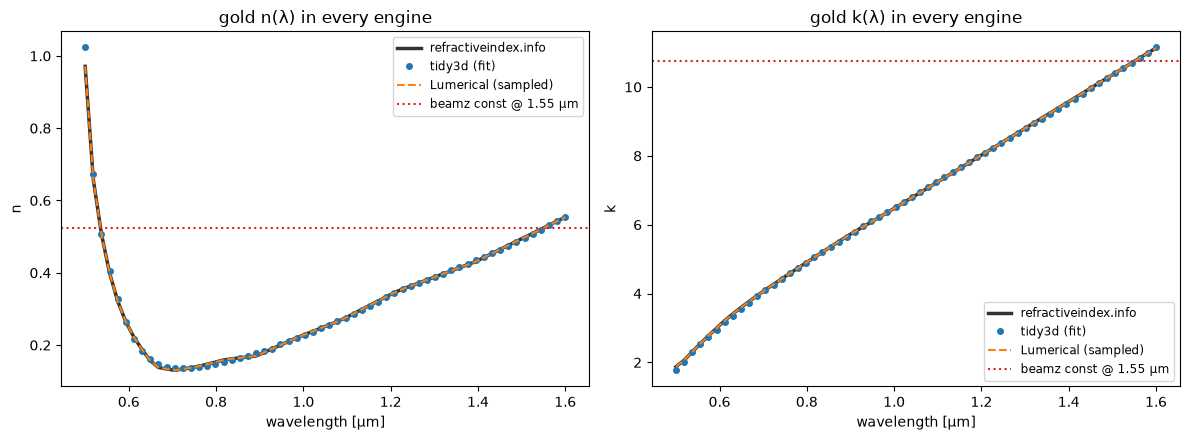

In [6]:
fig, (axn, axk) = plt.subplots(1, 2, figsize=(12, 4.5))
for ax, comp, rii, lab in ((axn, 0, n_rii, "n"), (axk, 1, k_rii, "k")):
    ax.plot(WL, rii, "-", lw=2.5, color="0.2", label="refractiveindex.info")
    ax.plot(WL, nk_td[:, comp], "o", ms=4, color="C0", label="tidy3d (fit)")
    if nk_lum is not None:
        ax.plot(WL, nk_lum[:, comp], "--", lw=1.5, color="C1", label="Lumerical (sampled)")
    ax.axhline((nk_beamz.real, nk_beamz.imag)[comp], ls=":", color="C3",
               label=f"beamz const @ {DESIGN_WL} µm")
    ax.set(xlabel="wavelength [µm]", ylabel=lab, title=f"gold {lab}(λ) in every engine")
    ax.legend(fontsize="small")
fig.tight_layout()
plt.show()

## Using it in a simulation

`to_tidy3d_medium()` returns a real `td.Medium` you can assign to any
structure, and the Lumerical sampled material is a named material like any
other — so a device built with a refractiveindex.info model runs exactly like
one built with a vendor model:

```python
medium = load_rii_material("main", "Si", "Salzberg").to_tidy3d_medium()
structure = td.Structure(geometry=..., medium=medium)   # dispersive Si, from rii
```

## Doing this from the technology file

You rarely call these by hand. In the tech file, give a material an `rii:`
reference and (optionally) `source: rii`, and **every** engine builds its
material from that model automatically — tidy3d a dispersive medium, Lumerical
a sampled material, beamz a constant:

```yaml
materials:
  Si:
    nk: 3.476
    rii: {shelf: main, book: Si, page: Salzberg}
    source: rii        # force the rii model on every engine (omit for eda→rii→nk)
```

The selection rule (per material, per engine) is **eda → rii → nk**, with
`source:` as an explicit override and a clear error if nothing applies — see
`docs/technology.rst` → *Material sources*.

## Recap

A refractiveindex.info page is a portable, engine-independent source of truth:
its full `n(λ) + i·k(λ)` flows into tidy3d (a dispersion fit) and Lumerical (a
sampled material) intact, and into beamz as a single-wavelength constant. Pick
your material once, run it anywhere.